<a href="https://colab.research.google.com/github/nicole-kutswa/credit-risk-analysis-model/blob/main/Credit_risk_modeling_using_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [82]:
path= "/content/drive/MyDrive/Projects/Credit Risk Modelling/german_credit_data.csv"

In [83]:
df= pd.read_csv(path)
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [84]:
df['Risk'].value_counts()

,count
Risk,
good,700
bad,300


In [85]:
df.shape

(1000, 11)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [87]:
df.describe(include= "all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [88]:
df['Job'].unique()

array([2, 1, 3, 0])

In [89]:
df.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df= df.dropna().reset_index(drop= True)
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [92]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [93]:
df.drop(columns= 'Unnamed: 0', inplace= True)

In [94]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

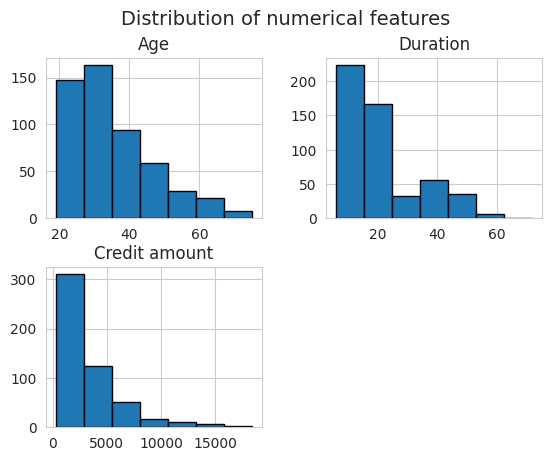

In [95]:
df[['Age', 'Duration', 'Credit amount']].hist(bins=7, edgecolor= 'black')
plt.suptitle('Distribution of numerical features', fontsize= 14)
plt.show()

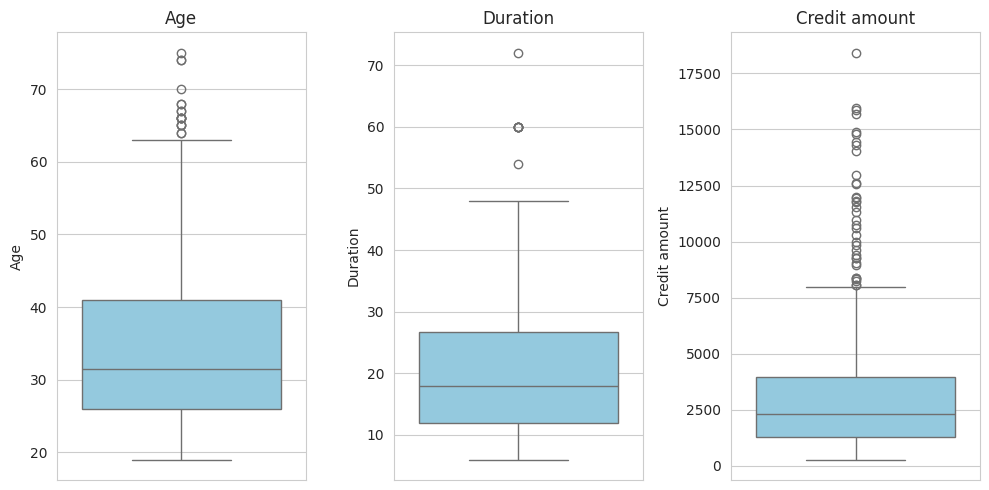

In [96]:
plt.figure(figsize= (10, 5))

for i, col in enumerate(['Age', 'Duration', 'Credit amount']):
  plt.subplot(1, 3, i+1)
  sns.boxplot(y= df[col], color= "skyblue")
  plt.title(col)

plt.tight_layout()
plt.show()

In [97]:
df.query("Duration>=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [98]:
categorical_cols= ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

/tmp/ipykernel_2234/3995940752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x= col, palette= "Set2", order= df[col].value_counts().index)
/tmp/ipykernel_2234/3995940752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x= col, palette= "Set2", order= df[col].value_counts().index)
/tmp/ipykernel_2234/3995940752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x= col, palette= "Set2", order= df[col].value_counts().index)
/tmp/ipykernel_2234/3995940752.py:4: FutureWarning: 

Passing `palette` with

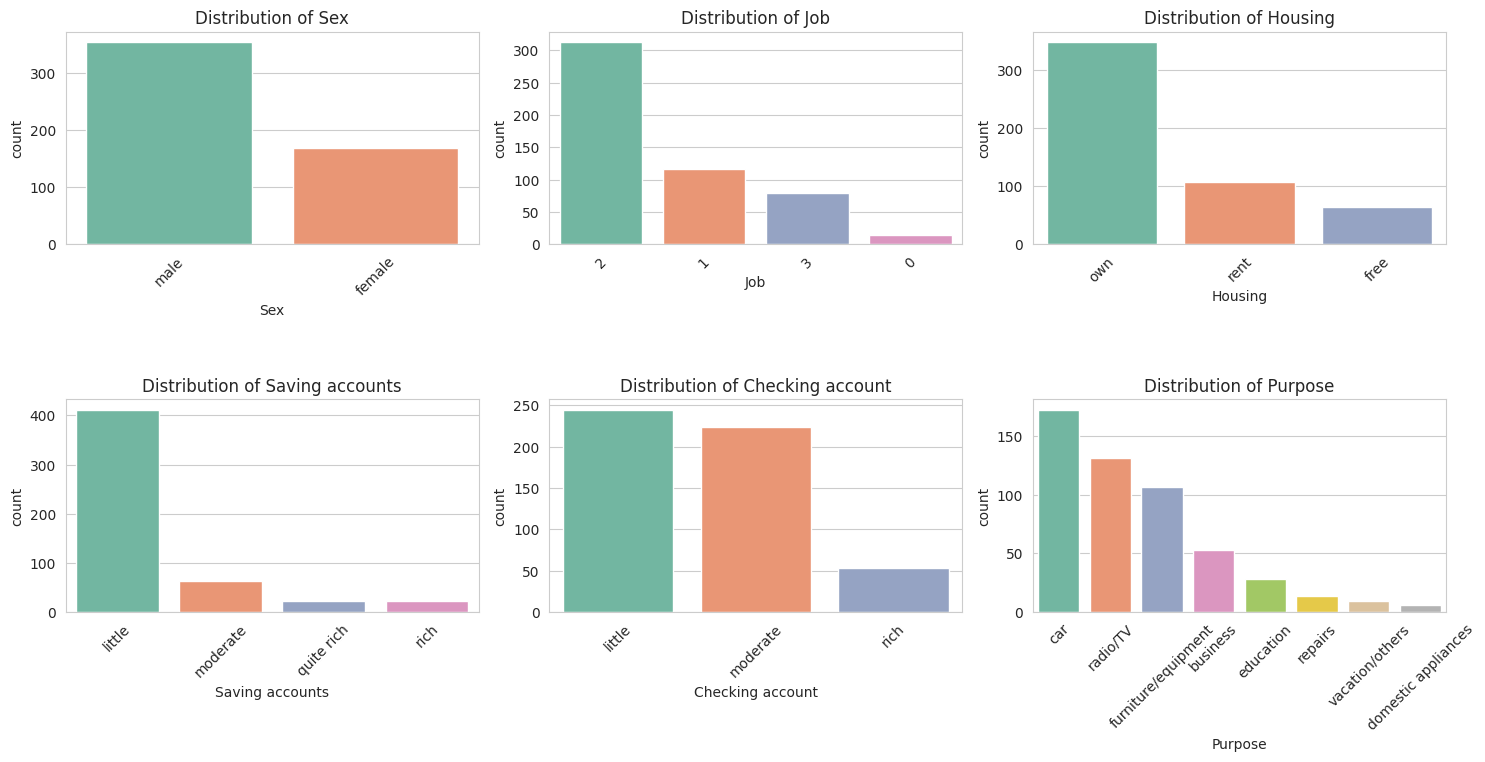

In [99]:
plt.figure(figsize= (15, 10))
for i, col in enumerate(categorical_cols):
  plt.subplot(3, 3, i+1)
  sns.countplot(data= df, x= col, palette= "Set2", order= df[col].value_counts().index)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation= 45)

plt.tight_layout()
plt.show()

In [100]:
corr= df[['Age', 'Job', 'Credit amount', 'Duration' ]].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


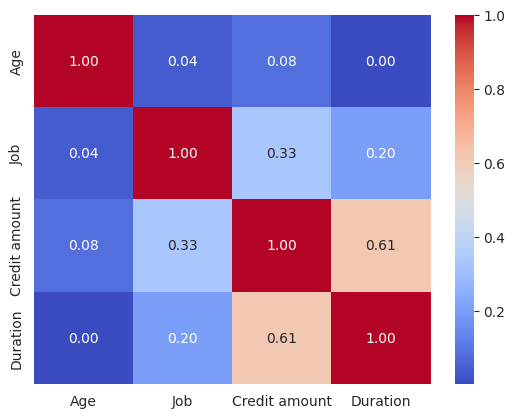

In [101]:
sns.heatmap(corr, annot= True, cmap= "coolwarm", fmt= ".2f")
plt.show()

In [102]:
df.groupby('Job')['Credit amount'].mean()

,Credit amount
Job,
0,1767.857143
1,2250.715517
2,3129.130990
3,5648.784810


In [103]:
df.groupby('Sex')['Credit amount'].mean()

,Credit amount
Sex,
female,2937.202381
male,3440.833333


In [104]:
df.pivot_table(values ='Credit amount', index= 'Housing', columns= 'Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


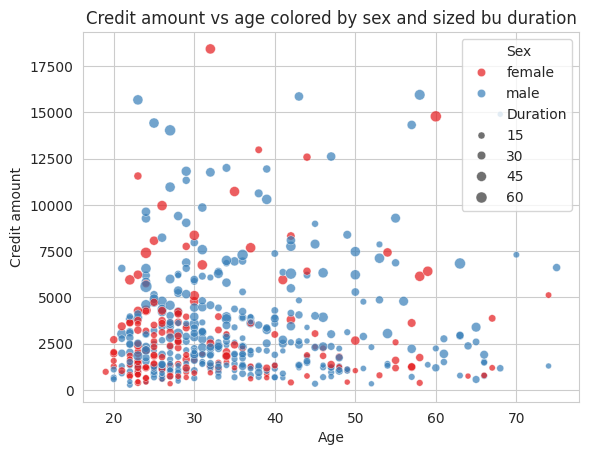

In [105]:
sns.scatterplot(data= df, x="Age", y= "Credit amount", hue= 'Sex', size= "Duration", alpha= 0.7, palette= "Set1")
plt.title("Credit amount vs age colored by sex and sized bu duration")
plt.show()

/tmp/ipykernel_2234/4239689755.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x="Saving accounts", y= "Credit amount", palette= "Pastel1")


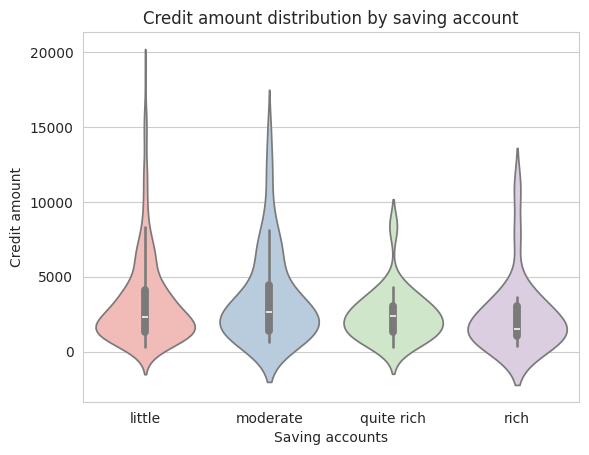

In [106]:
sns.violinplot(df, x="Saving accounts", y= "Credit amount", palette= "Pastel1")
plt.title("Credit amount distribution by saving account")
plt.show()

In [107]:
df['Risk'].value_counts(normalize= True)*100

,proportion
Risk,
good,55.747126
bad,44.252874


/tmp/ipykernel_2234/1748482321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x= 'Risk', y= col, palette= "Pastel2")
/tmp/ipykernel_2234/1748482321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x= 'Risk', y= col, palette= "Pastel2")
/tmp/ipykernel_2234/1748482321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x= 'Risk', y= col, palette= "Pastel2")


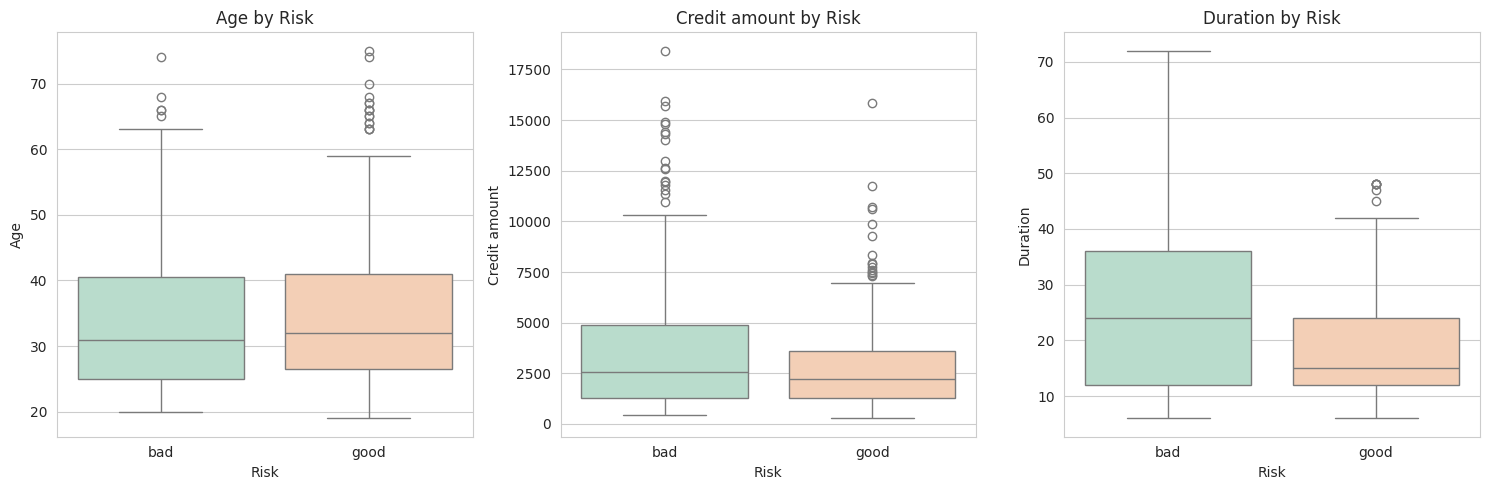

In [108]:
plt.figure(figsize= (15, 5))

for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
  plt.subplot(1, 3, i+1)
  sns.boxplot(df, x= 'Risk', y= col, palette= "Pastel2")
  plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [109]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


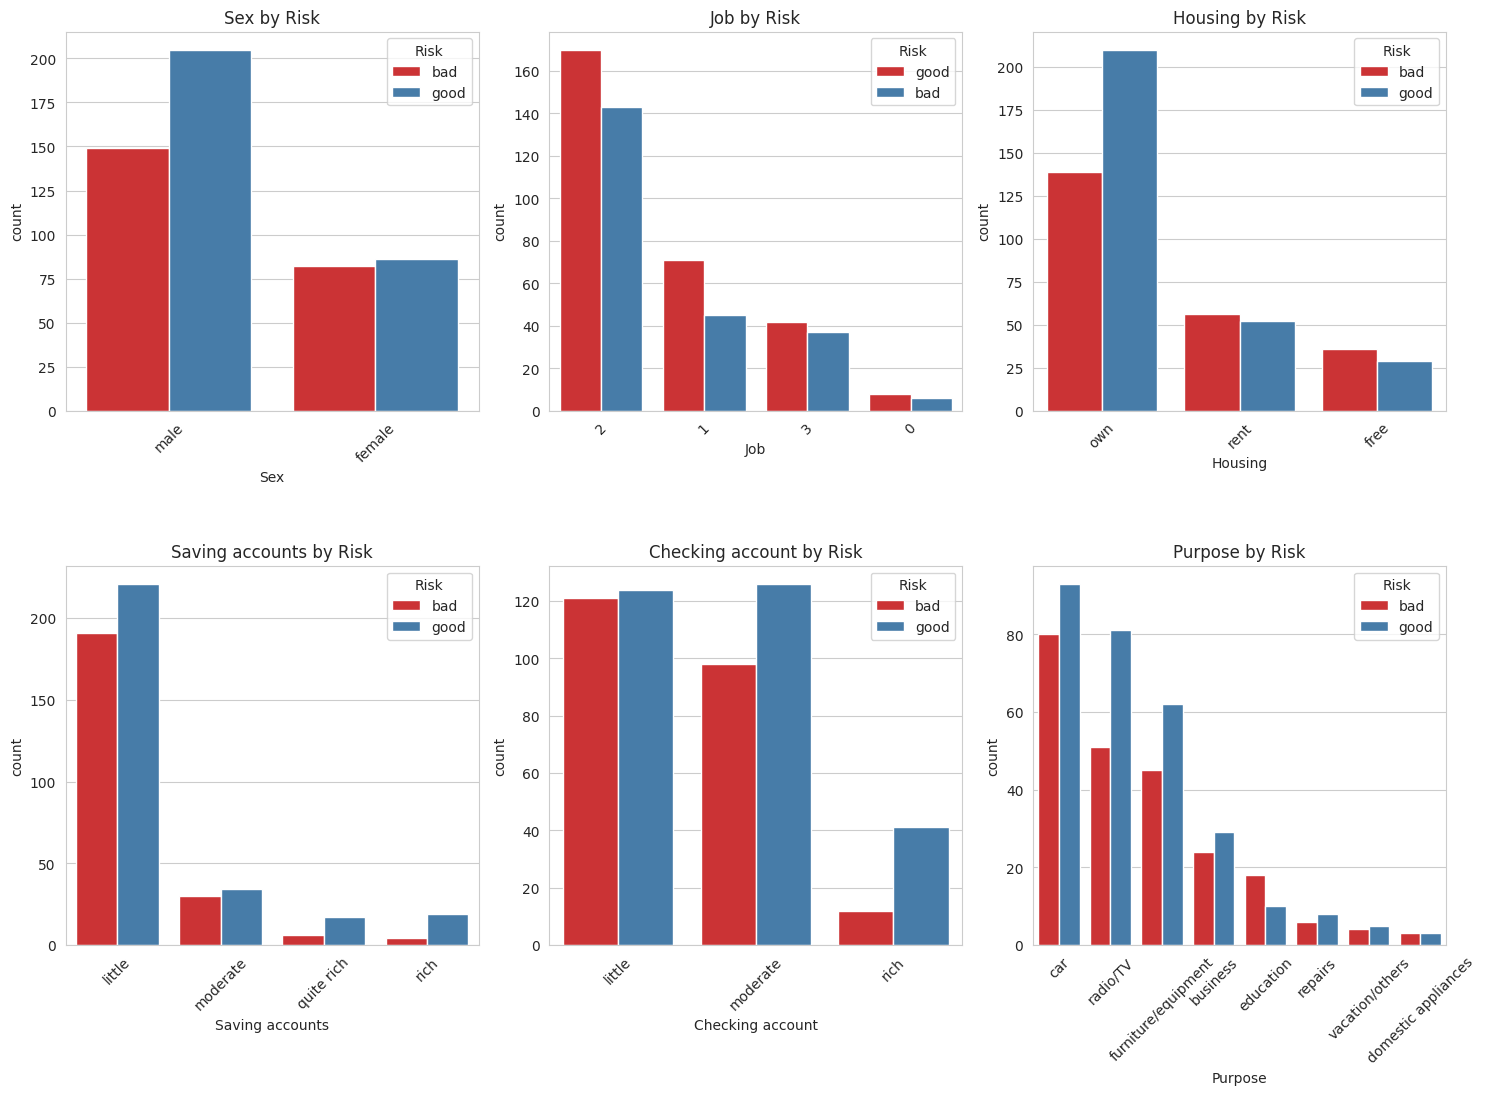

In [110]:
plt.figure(figsize= (15, 15))

for i, col in enumerate(categorical_cols):
  plt.subplot(3, 3, i+1)
  sns.countplot(data= df, x= col, hue= "Risk", palette= "Set1", order= df[col].value_counts().index)
  plt.title(f"{col} by Risk")
  plt.xticks(rotation= 45)

plt.tight_layout()
plt.show()

In [111]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [112]:
features= ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']
target= 'Risk'

In [113]:
df_model= df[features + [target]].copy()
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [114]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [115]:
cat_columns= df_model.select_dtypes(include= "object").columns.drop('Risk')


In [116]:
le_dict= {}

In [117]:
cat_columns

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [118]:
for col in cat_columns:
  le= LabelEncoder()
  df_model[col]= le.fit_transform(df_model[col])
  le_dict[col] = le
  joblib.dump(le, f"{col}_encoder.pkl")

In [119]:
le_target= LabelEncoder()


In [120]:
target

'Risk'

In [121]:
df_model[target]= le_target.fit_transform(df_model[target])

In [122]:
df_model[target].value_counts()

,count
Risk,
1,291
0,231


In [123]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [124]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [125]:
from sklearn.model_selection import train_test_split

In [126]:
X= df_model.drop(target, axis= 1)


In [127]:
y= df_model[target]

In [128]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [129]:
y

,Risk
0,0
1,1
2,0
3,1
4,0
...,...
517,1
518,1
519,1
520,0


In [130]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 42)

In [131]:
X_train.shape

(417, 8)

In [132]:
X_test.shape

(105, 8)

In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [134]:
def train_model( model, param_grid, X_train, y_train, X_test, y_test):
  grid= GridSearchCV(model, param_grid, cv= 5, scoring= "accuracy", n_jobs= -1)
  grid.fit(X_train, y_train)
  best_model= grid.best_estimator_
  y_pred= best_model.predict(X_test)
  acc= accuracy_score(y_test, y_pred)
  return best_model, acc, grid.best_params_

In [135]:
dt= DecisionTreeClassifier(random_state= 42, class_weight= "balanced")
dt_param_grid= {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [136]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (417, 8)
y_train: (417,)
X_test: (105, 8)
y_test: (105,)


In [137]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [138]:
print("Decision tree accuracy:", acc_dt)

Decision tree accuracy: 0.6


In [139]:
print("Best parameters:", params_dt)

Best parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [140]:
rf= RandomForestClassifier(random_state= 42, class_weight= "balanced", n_jobs= -1)

In [141]:
rf_param_grid= {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [142]:
best_rf, acc_rf, params_rf= train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [143]:
print("Random forest accuracy ", acc_rf)

Random forest accuracy  0.6285714285714286


In [144]:
etc= ExtraTreesClassifier(random_state= 1, class_weight= "balanced", n_jobs= -1)

In [145]:
etc_param_grid= {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [146]:
best_etc, acc_etc, params_etc =train_model(etc, etc_param_grid, X_train, y_train, X_test, y_test)

In [147]:
print("Extra Trees Classifier: ", acc_etc)

Extra Trees Classifier:  0.6095238095238096


In [148]:
print("Extra Trees Classifier parameters: ", params_etc)

Extra Trees Classifier parameters:  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [149]:
xgb= XGBClassifier(random_state= 1, scale_pos_weight= (y_train==0).sum()/(y_train==1).sum(),use_label_encoder= False, eval_metric= "logloss")

In [150]:
xgb_param_grid= {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 0.1],
    "colsample_bytree": [0.7, 1]
    }

In [151]:
best_xgb, acc_xgb, params_xgb= train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:29:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [152]:
print("XGB score: ", acc_xgb)

XGB score:  0.7238095238095238


In [153]:
print('Params XGB: ', params_xgb)

Params XGB:  {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}


In [154]:
joblib.dump(best_xgb, "xgb_credit_model.pkl")

['xgb_credit_model.pkl']

In [166]:
!pip install pyngrok streamlit -q

In [165]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model= joblib.load("/content/xgb_credit_model.pkl")
encoders= {col: joblib.load(f"{col}_encoder.pkl")for col in ["Sex", "Housing", "Saving accounts", "Checking account"]}

st.title("Credit Risk Prediction App")
st.write("Enter applicant information to predict if the credit risk is good or bad")

age= st.number_input("Age", min_value= 18, max_value= 80)
sex= st.selectbox("Sex", ["male", "female"])
job= st.number_input("Job (0-3)", min_value= 0, max_value= 3, value= 1)
housing= st.selectbox("Housing", ["own", "rent", "free"])
saving_accounts= st.selectbox("Saving Account", ["little","moderate", "rich", "quite rich"])
checking_account= st.selectbox("Checking Account", ['moderate', 'little', 'rich'])
credit_amount= st.number_input("Credit Amount", min_value= 0, value= 1000)
duration= st.number_input("Duration (months)", min_value= 1, value= 12)

input_df= pd.DataFrame({
  "Age": [age],
  "Sex": [encoders["Sex"].transform([sex])[0]],
  "Job": [job],
  "Housing": [encoders["Housing"].transform([housing])[0]],
  "Saving accounts": [encoders["Saving accounts"].transform([saving_accounts])[0]],
  "Checking account": [encoders["Checking account"].transform([checking_account])[0]],
  "Credit amount": [credit_amount],
  "Duration": [duration]
})


if st.button("Predit Risk"):
  pred= model.predict(input_df)[0]

  if pred==1:
    st.success("The predicted credit risk is: **GOOD**")
  else:
    st.error("The predicted credit risk is: **BAD**")





Overwriting app.py


In [167]:
from pyngrok import ngrok
import os

# 1. Authenticate your session
NGROK_TOKEN = '3Gid8t2zRL3vZGRZgDZ4HbMVQv7_2To3agTUUU3L1KX8tct9V'
os.system(f"ngrok config add-authtoken {NGROK_TOKEN}")

# 2. Kill any old background tunnels just in case
ngrok.kill()

# 3. Open a stable tunnel to port 8501
public_url = ngrok.connect(8501, proto="http")
print(" CLICK THIS URL TO OPEN APP:", public_url.public_url)

# 4. Start the Streamlit app in the background
!streamlit run app.py --server.port 8501

 CLICK THIS URL TO OPEN APP: https://overblown-amused-unrevised.ngrok-free.dev


2026-07-19 10:53:31.052 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.147.227:8501



  Stopping...
  Stopping...


In [168]:
!git config --global user.name "nicole-kutswa"
!git config --global user.email "nicolekutswa@example.com"

In [ ]:
!git clone https://github.com/nicole-kutswa/your-repo-name.git